In [1]:
# STEP 1: Import libraries and load the dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

df = pd.read_csv("DS.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (10954, 11)


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,SNWD,TAVG,TMAX,TMIN
0,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/1/1993,0.0,10.0,-8.3,NaN,NaN
1,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/2/1993,NaN,10.0,-14.9,NaN,NaN
2,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/3/1993,0.0,10.0,-13.6,-9.7,NaN
3,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/4/1993,0.0,10.0,-10.5,-6.5,-13.3
4,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1/5/1993,0.0,10.0,-12.0,-8.9,-14.1


In [2]:
# STEP 2: Create tomorrow's rain target

df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Use the next calendar day's precipitation to create the target.
df["Next_DATE"] = df["DATE"].shift(-1)
df["Next_PRCP"] = df["PRCP"].shift(-1)

# Keep only rows where the next record is truly the next day.
df["Consecutive"] = (
    (df["Next_DATE"] - df["DATE"]).dt.days == 1
)

# 1 = Rain tomorrow, 0 = No rain tomorrow
df["RainTomorrow"] = np.where(
    df["Next_PRCP"].isna(),
    np.nan,
    (df["Next_PRCP"] > 0).astype(int)
)

df = df[df["Consecutive"]].dropna(
    subset=["RainTomorrow"]
).copy()

df["RainTomorrow"] = df["RainTomorrow"].astype(int)

print("Usable rows:", len(df))

display(
    df[[
        "DATE", "TAVG", "TMAX", "TMIN",
        "PRCP", "RainTomorrow"
    ]].head()
)


Usable rows: 9156


,DATE,TAVG,TMAX,TMIN,PRCP,RainTomorrow
1,1993-01-02,-14.9,NaN,NaN,NaN,0
2,1993-01-03,-13.6,-9.7,NaN,0.0,0
3,1993-01-04,-10.5,-6.5,-13.3,0.0,0
5,1993-01-06,-2.3,NaN,-12.9,NaN,1
8,1993-01-09,0.9,NaN,NaN,NaN,1


In [3]:
# STEP 3: Select features and split data chronologically

df["MONTH"] = df["DATE"].dt.month
df["DAY_OF_YEAR"] = df["DATE"].dt.dayofyear

features = [
    "TAVG", "TMAX", "TMIN",
    "PRCP", "SNWD",
    "MONTH", "DAY_OF_YEAR"
]

X = df[features]
y_rain = df["RainTomorrow"]

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

rain_train = y_rain.iloc[:train_end].copy()
rain_val = y_rain.iloc[train_end:val_end].copy()
rain_test = y_rain.iloc[val_end:].copy()

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))


Train: 6409
Validation: 1373
Test: 1374


In [4]:
# STEP 4: Compare two preprocessing methods

rain_preprocess_results = []

for method in ["Median", "Median + Indicators"]:

    if method == "Median":
        imp = SimpleImputer(strategy="median")
    else:
        imp = SimpleImputer(strategy="median", add_indicator=True)

    Xtr = imp.fit_transform(X_train)
    Xv = imp.transform(X_val)

    rain_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rain_model.fit(Xtr, rain_train)
    rain_pred = rain_model.predict(Xv)

    rain_f1 = f1_score(
        rain_val, rain_pred, zero_division=0
    )

    rain_preprocess_results.append(
        [method, rain_f1]
    )

rain_pre_df = pd.DataFrame(
    rain_preprocess_results,
    columns=["Method", "F1"]
).sort_values("F1", ascending=False)

print("Rain preprocessing comparison:")
display(rain_pre_df)

best_rain_method = rain_pre_df.iloc[0]["Method"]

print("Best rain preprocessing:", best_rain_method)


Rain preprocessing comparison:


,Method,F1
0,Median,0.546119
1,Median + Indicators,0.531693


Best rain preprocessing: Median


In [5]:
# STEP 5: Apply selected preprocessing

rain_imputer = SimpleImputer(
    strategy="median",
    add_indicator=(best_rain_method == "Median + Indicators")
)

X_rain_train = rain_imputer.fit_transform(X_train)
X_rain_val = rain_imputer.transform(X_val)


In [6]:
# STEP 6: Tune Random Forest Classifier

rain_results = []

for trees in [50, 100, 200]:
    for depth in [5, 10, None]:

        model = RandomForestClassifier(
            n_estimators=trees,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_rain_train, rain_train)
        pred = model.predict(X_rain_val)

        score = f1_score(
            rain_val, pred, zero_division=0
        )

        rain_results.append(
            [trees, depth, score]
        )

rain_results = pd.DataFrame(
    rain_results,
    columns=["Trees", "Depth", "F1"]
).sort_values("F1", ascending=False)

display(rain_results)

best_rain_trees = int(rain_results.iloc[0]["Trees"])
best_rain_depth = rain_results.iloc[0]["Depth"]

if pd.isna(best_rain_depth):
    best_rain_depth = None
else:
    best_rain_depth = int(best_rain_depth)

print("Best trees:", best_rain_trees)
print("Best depth:", best_rain_depth)


,Trees,Depth,F1
1,50,10.0,0.546789
4,100,10.0,0.546119
7,200,10.0,0.537830
3,100,5.0,0.528302
8,200,NaN,0.524150
6,200,5.0,0.522814
0,50,5.0,0.521905
2,50,NaN,0.515723
5,100,NaN,0.513051


Best trees: 50
Best depth: 10


In [7]:
# STEP 7: Train final rain model using Train + Validation data

X_train_final = pd.concat([X_train, X_val])
rain_train_final = pd.concat([rain_train, rain_val])

final_rain_imputer = SimpleImputer(
    strategy="median",
    add_indicator=(best_rain_method == "Median + Indicators")
)

X_rain_final = final_rain_imputer.fit_transform(
    X_train_final
)

X_rain_test = final_rain_imputer.transform(
    X_test
)

final_rain_model = RandomForestClassifier(
    n_estimators=best_rain_trees,
    max_depth=best_rain_depth,
    random_state=42,
    n_jobs=-1
)

final_rain_model.fit(
    X_rain_final, rain_train_final
)


RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)

RAIN TEST RESULTS
Accuracy: 0.622
Precision: 0.589
Recall: 0.476
F1: 0.526


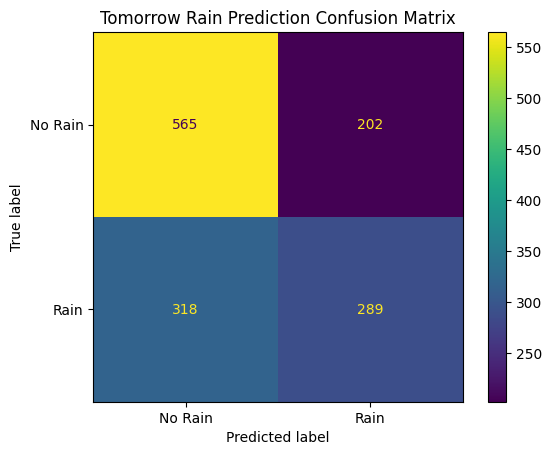

In [8]:
# STEP 8: Final rain evaluation

rain_test_pred = final_rain_model.predict(
    X_rain_test
)

print("RAIN TEST RESULTS")
print(
    "Accuracy:",
    round(accuracy_score(rain_test, rain_test_pred), 3)
)
print(
    "Precision:",
    round(precision_score(
        rain_test, rain_test_pred,
        zero_division=0
    ), 3)
)
print(
    "Recall:",
    round(recall_score(
        rain_test, rain_test_pred,
        zero_division=0
    ), 3)
)
print(
    "F1:",
    round(f1_score(
        rain_test, rain_test_pred,
        zero_division=0
    ), 3)
)

cm = confusion_matrix(
    rain_test,
    rain_test_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Rain", "Rain"]
).plot()

plt.title("Tomorrow Rain Prediction Confusion Matrix")
plt.show()


In [9]:
# STEP 9: Show one final tomorrow rain prediction

example = X_test.iloc[[0]]

predicted_rain = final_rain_model.predict(
    final_rain_imputer.transform(example)
)[0]

print(
    "Tomorrow rain prediction:",
    "Rain" if predicted_rain == 1 else "No Rain"
)


Tomorrow rain prediction: No Rain
